# WP4 period prior, Middleback-type branch (Annex B)

A second concept beside the sediment-hosted branch of `wp4_period_prior_sediment_hosted.ipynb`: the dense body under a coincident gravity and magnetic high is a lens of banded iron formation in the basement, enriched in places to hematite ore (Middleback type, Iron Knob and Iron Monarch, mined since 1900). The branch is barren for copper; the basalt piles it contains are barren flows. It is the alternative that WP4 Task 3 names for the anomaly WMC drilled.

**Shared setting by import, not by copy.** Level 1 (frame and horsts), the barren basalt piles of Level 2, the Level 5 basement fields and property assembly, the Part 0 anomaly rule, the forward operator and the observed surveys are imported from `09_sherlock/svoi_core.py`, the module generated from the sediment-hosted notebook. Only Levels 2 (lenses), 3 (belt) and 4 (enrichment) are defined here. Rerunning or changing the basalt sampler never touches this notebook, and both branches are guaranteed the same frame, fields, operator and data, which is the condition for comparing them.

Run from the `SVOI_OD` folder. Inputs: `01_citation_table/wp4_annexB_citation_table_draft.csv` (the Middleback rows; shared rows stay in Annex A), `06_sources/iron_oxide_bodies_middleback/`. Outputs: `08_prior_models/middleback/`.

1. Setup: figure style, the shared core, the Annex B rows
2. Part A. The branch (Steps 0 to 5): the lens, belt and enrichment stages; level figures; the five levels on one section; the 50-realization row check
3. Part B. Prior predictive check (Steps 6 to 9): one realization against the surveys; the 200-member ensemble; the gate; the falsification test
4. Part C. Versioned record (Step 10)

Rows marked *to elicit* carry working ranges translated from the Middleback statements already transcribed in `06_sources/iron_oxide_bodies_middleback/middleback_pre_t0_statements.csv`; `cited_b()` checks that the code uses the numbers written in each row and reports the row's status instead of asserting it confirmed.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data and the shared core

`svoi_core` prints its setup (grid, surveys, rule) on import; it is silenced here and summarised below. Nothing in it is changed by this notebook.

In [2]:
import sys, io, contextlib, re, json, time, hashlib, datetime
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import ndimage

sys.path.insert(0, "09_sherlock")
with contextlib.redirect_stdout(io.StringIO()):
    import svoi_core as C                                 # the shared setting: grid, rule, operator, surveys, Level 1, barren piles, Level 5
PM = Path("."); assert (PM / "01_citation_table").is_dir(), "run from the SVOI_OD folder"
OUT = Path("08_prior_models/middleback"); FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)
CB = pd.read_csv(PM / "01_citation_table/wp4_annexB_citation_table_draft.csv").set_index("row_id")

def cited_b(row, *numbers):
    """every number the code uses for an Annex B row must be written in that row; the status is reported, not asserted"""
    txt = CB.loc[row, "proposed_distribution"].replace(",", "")
    written = {float(x) for x in re.findall(r"\d+\.?\d*", txt)}
    for v in numbers:
        assert float(v) in written, (row, v, txt)
    return CB.loc[row, "status"]

print(f"shared core: grid {C.NX} x {C.NY} km, {len(C.ZC)} layers; {len(C.G_OBS)} gravity stations, {len(C.M_OBS):,} magnetic readings; "
      f"rule {C.RULE['T_grav_mgal']:g} mGal / {C.RULE['T_mag_nt']:g} nT; Annex A rows {len(C.CT)}, all confirmed: {bool(C.CT.confirmed.str.contains('confirmed').all())}")
print(f"Annex B rows: {len(CB)}"); print(CB[["parameter", "status"]].to_string())


shared core: grid 147 x 115 km, 90 layers; 398 gravity stations, 37,095 magnetic readings; rule 2 mGal / 20 nT; Annex A rows 17, all confirmed: True
Annex B rows: 9
                                                                                                 parameter                  status
row_id                                                                                                                            
B2-1                                                    BIF range intensity (count per 10,000 km2 of belt)  translated; to confirm
B2-2                                      BIF range dimensions: strike length; width; depth extent; strike  translated; to confirm
B2-4                                                           BIF fraction of the range (the rest schist)     declared; to elicit
B2-3                                            Banded iron formation (unenriched) density; susceptibility  translated; to confirm
B3-1                                             

## Part A. The branch

`realize_fe(seed)` draws the shared Annex A quantities with `C.draw` (frame, barren piles, cover and basement properties) in the same stream order as the sediment-hosted branch, and each Annex B stage draws its own rows when it runs, after Level 1 and the piles have consumed the stream; so for a given seed **Level 1 and the piles are identical in both branches**, and only the basement fields of Level 5 differ, as a different draw from the same prior. The stages run in the order frame, piles, belt, lenses, enrichment, basement fields. Depth $z$ is positive down; $g(\mathbf{x};\ell_\parallel,\ell_\perp,\theta)$ is the shared anisotropic Gaussian field.

1. **Level 1, frame** [Annex A, L1-1 to L1-3, Change 9]: imported. Cover stack, basement surface, a horst under each O'Driscoll target.
2. **Level 2, objects.** *Barren basalt piles* [Annex A, L2-1 to L2-3]: imported unchanged; they are flows with no copper. *BIF ranges* [B2-1, B2-2, B2-4]: a Poisson number, intensity $\lambda_{Fe}$ per $10^4$ km$^2$ of **belt** area, centres uniform inside the belt of Level 3; each range a north-south ellipse of length LogU(1, 10) km and width LogU(0.1, 2) km, standing steeply in the basement from the unconformity down a depth extent LogU(200, 2000) m, and made of banded iron formation for a fraction U(0.3, 0.7) of its volume with schist between (the Middleback Range is BIF "interfingered with schist", not solid BIF). The range's density and susceptibility contrast are the BIF values scaled by that fraction, and a range narrower than a cell keeps its mass through a fill fraction. Unenriched BIF carries $\rho$ U(3.0, 3.6) and $k$ LogU(5,000, 50,000) [B2-3], one value each per realization.
3. **Level 3, belt.** Banded iron formation exists in belts: the exceedance set of an anisotropic field with correlation length $\ell_b/3$ along north-south and $\ell_b/30$ across (aspect 10, fixed), $\ell_b \sim$ LogU(20, 60) km [B3-2], cut at its $(1 - p)$ quantile with $p \sim$ U(0.01, 0.10) [B3-1]. The same construction as the reduced-facies field of Annex A with different numbers; it is the control that says where the host rock is.
4. **Level 4, enrichment.** Along each range, hematite ore bodies occur as a Poisson number at a rate U(0.1, 0.3) per km of strike (twelve along the 60 km of the Middleback Range), each at a random position on the range with a plan area LogU(0.03, 0.45) km$^2$ (Iron Knob to Iron Monarch) and an enrichment depth LogU(30, 150) m below the unconformity [B4-1]; each body carries grade U(60, 68) % Fe, density $4.3 + 0.0375\,(G - 60)$ g/cm$^3$ and $k$ LogU(50, 2,000) [B4-2]. Tonnage is plan area times depth times density, derived; the bodies are counted objects, so their size does not grow with the range. Copper is zero [B4-3]. This is where the branch gets its signature: enriched ore is denser and barely magnetic, unenriched BIF lighter and strongly magnetic, so Level 4 decides whether a range gives a gravity-only or a coincident anomaly.
5. **Level 5, properties** [Annex A, L5-2, L5-4]: imported for cover, piles and basement fields; the ranges and ore bodies are written into the volume here (lithology 9 BIF range, 10 hematite ore).

Declared settings without a row: north-south strike and aspect 10 of the belt, north-south strike of the ranges, the linear density-on-grade map, no lineament weighting of range centres (the targets were drawn for the basalt concept), fill fractions for sub-cell ranges and ore bodies.


In [3]:
# ---- the Annex B draws, tied to their rows --------------------------------------------------------------------------------
U, LU = C.U, C.LU
for row, nums in [("B2-1", (100, 500)), ("B2-2", (1, 10, 0.1, 2, 200, 2000)), ("B2-4", (0.3, 0.7)), ("B2-3", (3.0, 3.6, 5000, 50000)),
                  ("B3-1", (0.01, 0.10)), ("B3-2", (20, 60, 10)), ("B4-1", (0.1, 0.3, 0.03, 0.45, 30, 150)), ("B4-2", (60, 68, 4.3, 0.0375, 4.6, 50, 2000))]:
    print(f"{row}: {cited_b(row, *nums)}")
FIX_FE = dict(belt_aspect=10.0, belt_az=0.0, lens_az=0.0)      # declared: Middleback Range, 60 x 6 km, north-south (RB 33/00090)
LITH_FE = {**C.LITH, 9: "banded iron formation", 10: "hematite ore"}
A_UNUSED = [k for k in C.draw(np.random.default_rng(0)) if k[:2] in ("L3", "L4")]   # Annex A rows the Middleback branch does not use

def draw_fe(r):
    """the shared Annex A rows, in the same stream order as the sediment-hosted branch; the Annex B rows are drawn inside their
    stages, after Level 1 and the piles have consumed the stream, so for a given seed those two are identical in both branches"""
    p = C.draw(r)
    for k in A_UNUSED: p.pop(k)                                   # drawn to keep the stream aligned, not used by this branch
    return p

def level3_belt(r, p, F):
    p["B3-1 p_belt"] = U(r, 0.01, 0.10); p["B3-2 belt_length_km"] = LU(r, 20, 60)
    Lb = p["B3-2 belt_length_km"]
    f = C.grf(r, Lb / 3.0, Lb / 3.0 / FIX_FE["belt_aspect"], FIX_FE["belt_az"])
    return dict(belt=f >= np.quantile(f, 1 - p["B3-1 p_belt"]))

def level2_lenses(r, p, F):
    p["B2-1 lens_intensity_per_1e4km2_belt"] = LU(r, 100, 500); p["B2-3 rho_bif"] = U(r, 3.0, 3.6); p["B2-3 k_bif"] = LU(r, 5000, 50000)
    p["B2-4 bif_fraction"] = U(r, 0.3, 0.7)
    belt = F["belt"]; belt_km2 = belt.sum() * (C.DX / 1e3) ** 2
    n = r.poisson(p["B2-1 lens_intensity_per_1e4km2_belt"] * belt_km2 / 1e4) if belt.any() else 0
    lx, ly = C.weighted_points(r, n, np.ones((C.NY, C.NX)), belt)
    lid = np.zeros((C.NY, C.NX), int); lenses = []
    for j, (x, y) in enumerate(zip(lx, ly), 1):
        L = LU(r, 1, 10); w = LU(r, 0.1, 2.0); E = LU(r, 200, 2000)
        m = C.ellipse(x, y, L, L / w, FIX_FE["lens_az"])
        if not m.any(): m[np.argmin(abs(C.YC - y)), np.argmin(abs(C.XC - x))] = True
        area = np.pi * L * w / 4; fill = min(1.0, area / (m.sum() * (C.DX / 1e3) ** 2))
        lid[m & (lid == 0)] = j
        iy, ix = np.argmin(abs(C.YC - y)), np.argmin(abs(C.XC - x))
        lenses.append(dict(obj=j, x=x, y=y, length_km=L, width_km=w, depth_extent_m=E, fill=fill, fill_bif=fill * p["B2-4 bif_fraction"], area_km2=area, depth_m=float(F["base"][iy, ix])))
    return dict(lid=lid, lenses=lenses, irons=[], iid=np.zeros((C.NY, C.NX), int))    # irons empty: the Annex A iron slab is replaced by the lenses

def level4_enrich(r, p, F):
    p["B4-1 ore_bodies_per_km"] = U(r, 0.1, 0.3)
    enr = np.zeros((C.NY, C.NX), int); ores = []
    for o in F["lenses"]:
        cells_ = np.argwhere(F["lid"] == o["obj"])
        if len(cells_) == 0: continue
        n_b = r.poisson(p["B4-1 ore_bodies_per_km"] * o["length_km"])
        for _ in range(n_b):
            iy_, ix_ = cells_[r.integers(0, len(cells_))]                          # a random cell of the range
            area = LU(r, 0.03, 0.45); th = min(LU(r, 30, 150), o["depth_extent_m"])     # plan area (km2) and enrichment depth (m)
            G = U(r, 60, 68); rho = 4.3 + 0.0375 * (G - 60); kk = LU(r, 50, 2000)
            enr[iy_, ix_] = o["obj"]
            ores.append(dict(lens=o["obj"], x=float(C.XC[ix_]), y=float(C.YC[iy_]), iy=int(iy_), ix=int(ix_), grade=G, rho=rho, k=kk,
                             depth_m=float(F["base"][iy_, ix_]), thick_m=th, area_km2=area, fill=area / (C.DX / 1e3) ** 2, Mt=area * th * rho))   # km2 x m x t/m3 = Mt
    return dict(enr=enr, ores=ores)

def fe_properties(p, F):
    V = C.level5_properties(p, F)                                          # cover, barren piles, basement fields (shared)
    lith, rho3, k3, res3 = V["lith"], V["rho"], V["k"], V["res"]
    z = C.ZC[None, None, :]; base3 = F["base"][:, :, None]
    for o in F["lenses"]:                                                  # the range: BIF for a fraction of its volume, as a contrast scaled by fill x BIF fraction
        m3 = (F["lid"][:, :, None] == o["obj"]) & (lith == 7) & (z >= base3) & (z < base3 + o["depth_extent_m"])
        lith[m3] = 9
        rho3[m3] = rho3[m3] + o["fill_bif"] * (p["B2-3 rho_bif"] - rho3[m3]); k3[m3] = k3[m3] + o["fill_bif"] * (p["B2-3 k_bif"] - k3[m3])
    for o in F["ores"]:                                                    # each ore body replaces the rock of its cell over its plan area, from the unconformity down its depth
        zc = C.ZC; b0 = F["base"][o["iy"], o["ix"]]; kz = (zc >= b0) & (zc < b0 + o["thick_m"])
        lith[o["iy"], o["ix"], kz] = 10
        rho3[o["iy"], o["ix"], kz] += o["fill"] * (o["rho"] - rho3[o["iy"], o["ix"], kz]); k3[o["iy"], o["ix"], kz] += o["fill"] * (o["k"] - k3[o["iy"], o["ix"], kz])
    return dict(lith=lith, rho=rho3, k=k3, res=res3)

def fe_summary(p, F):
    L, O = F["lenses"], F["ores"]
    return {"L5-4 basement_sd": F["basement_sd"], "L5-4 basement_logk_sd": F["basement_logk_sd"],
            **dict(n_basalt=len(F["objs"]), basalt_frac=F["basalt"].mean(), belt_frac=F["belt"].mean(), belt_km2=F["belt"].sum() * (C.DX / 1e3) ** 2,
                   n_lens=len(L), lens_km2=sum(o["area_km2"] for o in L), n_ore=len(O), Fe_Mt_total=sum(o["Mt"] for o in O),
                   Fe_Mt_max=max([o["Mt"] for o in O], default=0.0), basement_sd_realized=F["rho_base"].std())}

BRANCH_FE = dict(name="Middleback-type iron body, Annex B", citation_table="01_citation_table/wp4_annexB_citation_table_draft.csv",
                 geometry_family="steep BIF ranges (BIF interfingered with schist) in belts of the basement, below the unconformity; barren basalt flows on it",
                 mineralization_rule="hematite ore bodies, a Poisson number per km of range, each of Middleback plan area, from the unconformity down; no copper",
                 draw=draw_fe, stages=[C.level1_frame, C.level2_basalt, level3_belt, level2_lenses, level4_enrich, C.level5_basement],
                 properties=fe_properties, summary=fe_summary)

def realize_fe(seed, keep_volume=False):
    return C.realize_branch(BRANCH_FE, seed, keep_volume)

def synthetic_fe(seed, rng_noise=True):
    out, maps, objs, ores = realize_fe(seed, keep_volume=True)
    g, t = C.forward(maps["rho"], maps["k"])
    r = np.random.default_rng(seed + 10_000_000)
    gs = C.sample(g, C.GXo, C.GYo) + (r.normal(0, C.G_SD) if rng_noise else 0)
    ms = C.sample(t, C.MXo, C.MYo) + (r.normal(0, C.RULE["mag_noise_nt"], len(C.MXo)) if rng_noise else 0)
    return out, maps, g, t, gs, ms

o43, m43, b43, e43 = realize_fe(43)
oA, mA, bA, _ = C.realize(43)
print("branch:", BRANCH_FE["name"]); print("  stages:", [f.__name__ for f in BRANCH_FE["stages"]], "+", BRANCH_FE["properties"].__name__)
print(f"seed 43: Level 1 identical to the sediment-hosted branch: {np.array_equal(m43['base'], mA['base'])}; piles identical: {len(b43) == len(bA) and np.allclose(b43[['x', 'y', 'length_km']].values, bA[['x', 'y', 'length_km']].values)}")
print(f"seed 43: belt {o43['belt_frac']*100:.1f}% of the window ({o43['belt_km2']:.0f} km2), {o43['n_lens']} ranges, {o43['n_ore']} ore bodies, {o43['Fe_Mt_total']:.0f} Mt Fe ore")


B2-1: translated; to confirm
B2-2: translated; to confirm
B2-4: declared; to elicit
B2-3: translated; to confirm
B3-1: declared; to elicit
B3-2: translated; to confirm
B4-1: translated; to confirm
B4-2: translated; to confirm
branch: Middleback-type iron body, Annex B
  stages: ['level1_frame', 'level2_basalt', 'level3_belt', 'level2_lenses', 'level4_enrich', 'level5_basement'] + fe_properties
seed 43: Level 1 identical to the sediment-hosted branch: True; piles identical: True
seed 43: belt 3.4% of the window (575 km2), 6 ranges, 6 ore bodies, 325 Mt Fe ore


### Step 0. Prior distributions

One panel per sampled quantity, in level order and coloured by level. Rows L are the shared ones this branch draws through `C.draw` (frame, barren piles, cover and basement properties), whose sources are in the sediment-hosted notebook; rows B are this branch's own (ranges, belt, ore bodies).

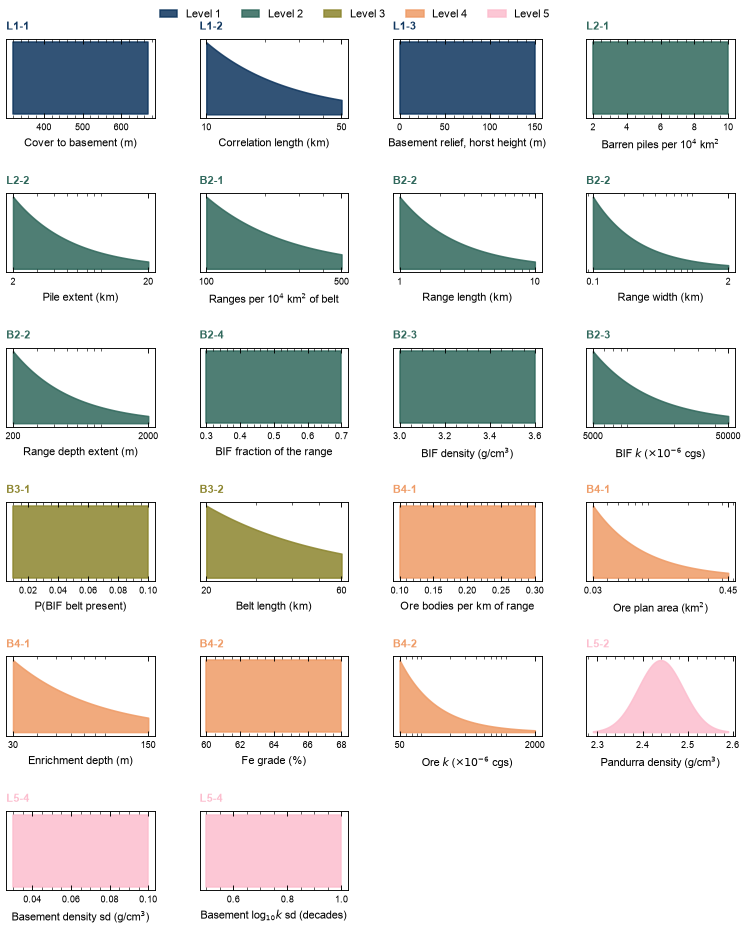

Annex B rows: flat blocks, every one a range translated from the Middleback statements, none a mode; the density-on-grade map is deterministic. Shared rows: see the sediment-hosted notebook, Step 0.


In [4]:
PANELS_B = [("B2-1", "Ranges per 10$^4$ km$^2$ of belt", ("lu", 100, 500)), ("B2-2", "Range length (km)", ("lu", 1, 10)),
            ("B2-2", "Range width (km)", ("lu", 0.1, 2)), ("B2-2", "Range depth extent (m)", ("lu", 200, 2000)), ("B2-4", "BIF fraction of the range", ("u", 0.3, 0.7)),
            ("B2-3", "BIF density (g/cm$^3$)", ("u", 3.0, 3.6)), ("B2-3", "BIF $k$ ($\\times10^{-6}$ cgs)", ("lu", 5000, 50000)),
            ("B3-1", "P(BIF belt present)", ("u", 0.01, 0.10)), ("B3-2", "Belt length (km)", ("lu", 20, 60)),
            ("B4-1", "Ore bodies per km of range", ("u", 0.1, 0.3)), ("B4-1", "Ore plan area (km$^2$)", ("lu", 0.03, 0.45)), ("B4-1", "Enrichment depth (m)", ("lu", 30, 150)),
            ("B4-2", "Fe grade (%)", ("u", 60, 68)), ("B4-2", "Ore $k$ ($\\times10^{-6}$ cgs)", ("lu", 50, 2000))]
PANELS_A = [("L1-1", "Cover to basement (m)", ("u", 320, 670)), ("L1-2", "Correlation length (km)", ("lu", 10, 50)), ("L1-3", "Basement relief, horst height (m)", ("u", 0, 150)),
            ("L2-1", "Barren piles per 10$^4$ km$^2$", ("u", 2, 10)), ("L2-2", "Pile extent (km)", ("lu", 2, 20)), ("L5-2", "Pandurra density (g/cm$^3$)", ("n", 2.44, 0.05)),
            ("L5-4", "Basement density sd (g/cm$^3$)", ("u", 0.03, 0.10)), ("L5-4", "Basement log$_{10}k$ sd (decades)", ("u", 0.5, 1.0))]
LEVEL_COL = {k: BATLOW(v) for k, v in zip(range(1, 6), (0.08, 0.30, 0.52, 0.74, 0.92))}
from matplotlib.ticker import LogLocator, NullFormatter, FormatStrFormatter
fig, axes = plt.subplots(6, 4, figsize=(COL2, 8.6)); fig.subplots_adjust(left=0.06, right=0.98, top=0.96, bottom=0.06, wspace=0.3, hspace=0.95)
for ax in axes.ravel()[len(PANELS_B) + len(PANELS_A):]: ax.set_visible(False)
PANELS = sorted(PANELS_A + PANELS_B, key=lambda t: (int(t[0][1]), t[0][0] == "B"))      # level order, shared rows before the branch rows within a level
for ax, (row, lab, d) in zip(axes.ravel(), PANELS):
    col = LEVEL_COL[int(row[1])]
    if d[0] == "u":
        x = np.linspace(d[1], d[2], 2); ax.fill_between(x, 0, 1 / (d[2] - d[1]), color=col, alpha=0.85)
    elif d[0] == "n":
        x = np.linspace(d[1] - 3 * d[2], d[1] + 3 * d[2], 100); ax.fill_between(x, 0, np.exp(-0.5 * ((x - d[1]) / d[2]) ** 2), color=col, alpha=0.85)
    else:
        x = np.geomspace(d[1], d[2], 100); ax.fill_between(x, 0, 1 / (x * np.log(d[2] / d[1])), color=col, alpha=0.85); ax.set_xscale("log")
        ax.xaxis.set_major_locator(LogLocator(base=10, numticks=4)); ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks([d[1], d[2]], minor=False); ax.xaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.set_yticks([]); ax.set_xlabel(lab, fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1)
    ax.set_title(row, loc="left", fontsize=FS_ANNOT, color=col, fontweight="bold")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=LEVEL_COL[k], alpha=0.85, label=f"Level {k}") for k in (1, 2, 3, 4, 5)],
           loc="upper center", ncol=5, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.savefig(FIG / "wp4_FE_00_priors.png", dpi=300); plt.show()
print("Annex B rows: flat blocks, every one a range translated from the Middleback statements, none a mode; the density-on-grade map is deterministic. Shared rows: see the sediment-hosted notebook, Step 0.")


**Reading the figure.** Uniform on a linear axis, log-uniform on a log axis, one shaped prior (the Pandurra density). Level 1 and Level 5 rows are the shared frame and properties; among them the relief draw L1-3 is also the horst height under the targets, and the Pandurra density L5-2 sets the host of the piles. The Level 2 rows mix the shared piles (L2) with the ranges (B2); Levels 3 and 4 are this branch's belt and ore bodies. None of the B rows is yet confirmed against its source.

### Step 1. Levels 2 and 3: the BIF belt and the lenses (seeds 43, 77, 99)

The same three figure seeds as the sediment-hosted notebook, so the piles in each panel are the ones in its Step 2.

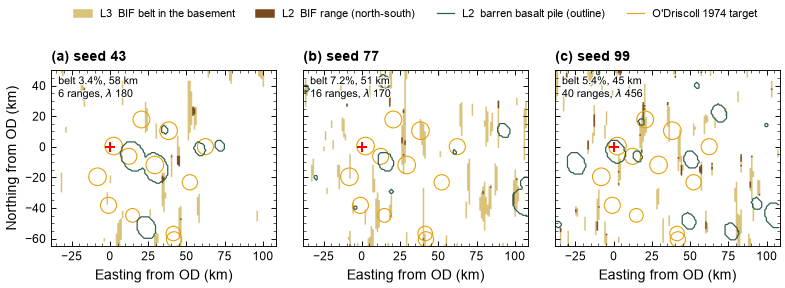

seed 43: belt 3.4% (575 km2), 6 ranges, length 1.0-8.7 km, width 321-1703 m, depth extent 427-1835 m
seed 77: belt 7.2% (1221 km2), 16 ranges, length 1.2-9.3 km, width 103-1766 m, depth extent 334-1940 m
seed 99: belt 5.4% (921 km2), 40 ranges, length 1.0-10.0 km, width 113-1712 m, depth extent 210-1959 m


In [5]:
OUT_, MAPS, OBJ, ORE = {}, {}, {}, {}
for s in (43, 77, 99):
    OUT_[s], MAPS[s], OBJ[s], ORE[s] = realize_fe(s, keep_volume=True)
ODX, ODY, XC, YC, X0, X1, Y0, Y1 = C.ODX, C.ODY, C.XC, C.YC, C.X0, C.X1, C.Y0, C.Y1
ext = [(X0 - ODX) / 1e3, (X1 - ODX) / 1e3, (Y0 - ODY) / 1e3, (Y1 - ODY) / 1e3]; xkm = (XC - ODX) / 1e3
iy = int(np.argmin(abs(YC - ODY)))
C_FE = dict(basalt="#2e5e4e", belt="#d9c27a", bif="#7a4a1e", ore="#20306f", target="#e69f00")
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7)); fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (43, 77, 99)):
    m = MAPS[s]; o = OUT_[s]
    ax.imshow(np.where(m["belt"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["belt"]]), aspect="equal")
    ax.contour(xkm, (YC - ODY) / 1e3, (m["bid"] > 0).astype(float), levels=[0.5], colors=C_FE["basalt"], linewidths=0.8)
    L = pd.DataFrame(m["lenses"])
    ax.imshow(np.where(m["lid"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["bif"]]), aspect="equal")
    for x, y, rr in zip(C.TX, C.TYY, C.TG.radius_km.values):
        ax.add_patch(plt.Circle(((x - ODX) / 1e3, (y - ODY) / 1e3), rr, fill=False, ec=C_FE["target"], lw=0.7))
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    ax.text(0.03, 0.97, f"belt {o['belt_frac']*100:.1f}%, {o['B3-2 belt_length_km']:.0f} km\n{o['n_lens']} ranges, $\\lambda$ {o['B2-1 lens_intensity_per_1e4km2_belt']:.0f}", transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, ("(a) seed 43", "(b) seed 77", "(c) seed 99"))
h = [plt.Rectangle((0, 0), 1, 1, color=C_FE["belt"], label="L3  BIF belt in the basement"), plt.Rectangle((0, 0), 1, 1, color=C_FE["bif"], label="L2  BIF range (north-south)"),
     plt.Line2D([], [], color=C_FE["basalt"], lw=0.8, label="L2  barren basalt pile (outline)"), plt.Line2D([], [], color=C_FE["target"], lw=0.7, label="O'Driscoll 1974 target")]
fig.legend(handles=h, loc="upper center", ncol=4, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.01), frameon=False)
fig.savefig(FIG / "wp4_FE_01_belt_lenses.png", dpi=300); plt.show()
for s in (43, 77, 99):
    L = pd.DataFrame(MAPS[s]["lenses"]); o = OUT_[s]
    print(f"seed {s}: belt {o['belt_frac']*100:.1f}% ({o['belt_km2']:.0f} km2), {o['n_lens']} ranges" + (f", length {L.length_km.min():.1f}-{L.length_km.max():.1f} km, width {L.width_km.min()*1e3:.0f}-{L.width_km.max()*1e3:.0f} m, depth extent {L.depth_extent_m.min():.0f}-{L.depth_extent_m.max():.0f} m" if len(L) else ""))


**Reading the figure.** Pale yellow is the BIF belt (Level 3), brown the ranges inside it (Level 2, north-south), green outlines the barren piles (the same piles as the sediment-hosted Step 2, by construction), amber the 1974 targets.
- Seeds 43, 77, 99: belt 3.4, 7.2 and 5.4% of the window (575, 1,221 and 921 km$^2$); 6, 16 and 40 ranges, 1.0 to 10 km long, 100 to 1,770 m wide, 210 to 1,960 m deep.
- With aspect 10 the belt is a set of narrow north-south slivers rather than one range; whether that is the right picture of a buried BIF belt is a question for row B3-2.

### Step 2. Level 4: enrichment to hematite ore

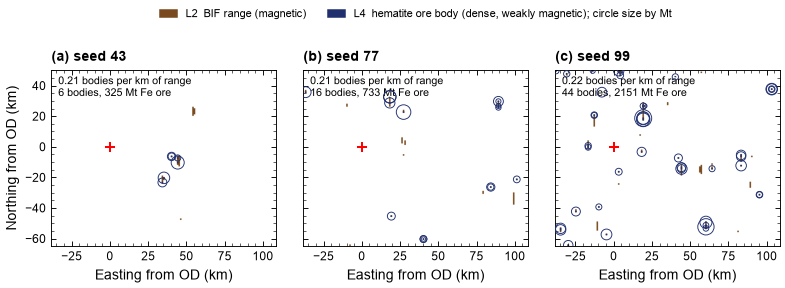

seed 43: 6 ore bodies, 17.0-111 Mt each (total 325), grade 62-67% Fe, density 4.39-4.57, k 95-1311; Middleback 1952: 12 bodies of 0.05 to 59 Mt
seed 77: 16 ore bodies, 4.4-141 Mt each (total 733), grade 60-68% Fe, density 4.32-4.59, k 64-1688; Middleback 1952: 12 bodies of 0.05 to 59 Mt
seed 99: 44 ore bodies, 4.7-196 Mt each (total 2151), grade 60-68% Fe, density 4.31-4.59, k 50-1691; Middleback 1952: 12 bodies of 0.05 to 59 Mt


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7)); fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (43, 77, 99)):
    m = MAPS[s]; e = ORE[s]; o = OUT_[s]
    ax.imshow(np.where(m["lid"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["bif"]]), aspect="equal")
    ax.imshow(np.where(m["enr"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["ore"]]), aspect="equal")
    if len(e): ax.scatter((e.x - ODX) / 1e3, (e.y - ODY) / 1e3, s=6 + 0.6 * e.Mt, facecolors="none", edgecolors=C_FE["ore"], linewidths=0.6, zorder=4)
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    ax.text(0.03, 0.97, f"{o['B4-1 ore_bodies_per_km']:.2f} bodies per km of range\n{o['n_ore']} bodies, {o['Fe_Mt_total']:.0f} Mt Fe ore", transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, ("(a) seed 43", "(b) seed 77", "(c) seed 99"))
h = [plt.Rectangle((0, 0), 1, 1, color=C_FE["bif"], label="L2  BIF range (magnetic)"), plt.Rectangle((0, 0), 1, 1, color=C_FE["ore"], label="L4  hematite ore body (dense, weakly magnetic); circle size by Mt")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.01), frameon=False)
fig.savefig(FIG / "wp4_FE_02_enrichment.png", dpi=300); plt.show()
for s in (43, 77, 99):
    e = ORE[s]
    print(f"seed {s}: {len(e)} ore bodies" + (f", {e.Mt.min():.1f}-{e.Mt.max():.0f} Mt each (total {e.Mt.sum():.0f}), grade {e.grade.min():.0f}-{e.grade.max():.0f}% Fe, density {e.rho.min():.2f}-{e.rho.max():.2f}, k {e.k.min():.0f}-{e.k.max():.0f}; Middleback 1952: 12 bodies of 0.05 to 59 Mt" if len(e) else ""))


**Reading the figure.** Brown is the BIF range, navy the cells that hold an ore body; the open circles scale with the ore tonnage.
- Seeds 43, 77, 99: 6, 16 and 44 ore bodies of 17 to 111, 4 to 141 and 5 to 196 Mt (totals 325, 733 and 2,151 Mt); grade 60 to 68% Fe, density 4.30 to 4.60, $k$ 50 to 2,000 x 1e-6 cgs.
- Miles's 1952 table: twelve bodies of 0.05 to 59 Mt, 176 Mt in all. The bodies here are Table II sizes with a tail above 59 Mt (the Monarch plan area at the deeper end of the enrichment range); the window carries several times the Middleback total because it holds several times the range length.

### Step 3. The five levels on one section

The west-east line at the Olympic Dam northing, as in the sediment-hosted notebook's Step 5b, for the seed among 100 to 399 whose line crosses the most range width (stated rule). Cover and piles are the shared Level 1 and 2; the ranges stand in the basement below the unconformity, the ore bodies at their top in navy, drawn with a width equal to the square root of their plan area. The margin bands of the basalt concept do not exist here: the branch has no reduced facies and no copper.

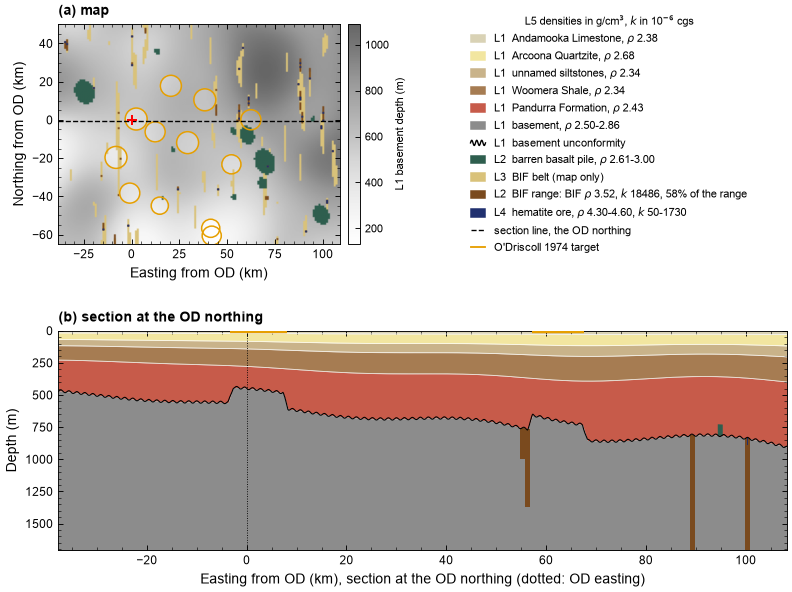

seed 218 (rule: most range width on the OD-northing line among seeds 100-399): 4 range(s) over 4 km of line, 1 ore body on the line; piles over 2 km
window: belt 5.7%, 42 ranges, 38 ore bodies, 1813 Mt Fe ore; relief draw 120 m (horst height under the targets)


In [7]:
def lens_km_on_line(s):
    o, m, _, _ = realize_fe(s); return int((m["lid"][iy] > 0).sum()), int((m["enr"][iy] > 0).sum())
cand = sorted(((lens_km_on_line(s), s) for s in range(100, 400)), reverse=True)
S5 = cand[0][1]; o5, m5, b5, e5 = realize_fe(S5, keep_volume=True)
L5 = pd.DataFrame(m5["lenses"]); UNIT_COL = {1: "#d9d2b5", 2: "#f2e6a0", 3: "#c9b38a", 4: "#a67c52", 5: "#c75b4a", 6: "#2e5e4e", 7: "#8c8c8c"}
fig = plt.figure(figsize=(COL2, 5.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1.0], hspace=0.30, wspace=0.42, left=0.07, right=0.99, top=0.96, bottom=0.08)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(m5["base"], origin="lower", extent=ext, cmap="Greys", alpha=0.6, aspect="equal")
ax.imshow(np.where(m5["belt"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["belt"]]), aspect="equal")
ax.imshow(np.where(m5["bid"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["basalt"]]), aspect="equal")
ax.imshow(np.where(m5["lid"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["bif"]]), aspect="equal")
ax.imshow(np.where(m5["enr"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap([C_FE["ore"]]), aspect="equal")
for x, y, rr in zip(C.TX, C.TYY, C.TG.radius_km.values): ax.add_patch(plt.Circle(((x - ODX) / 1e3, (y - ODY) / 1e3), rr, fill=False, ec=C_FE["target"], lw=1.0))
ax.axhline((YC[iy] - ODY) / 1e3, color="k", lw=0.9, ls="--"); ax.plot(0, 0, "+", color="red", ms=7, mew=1.3)
ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)"); ax.set_ylabel("Northing from OD (km)")
from mpl_toolkits.axes_grid1 import make_axes_locatable
cax = make_axes_locatable(ax).append_axes("right", size="4%", pad=0.08); cb = fig.colorbar(im, cax=cax); cb.set_label("L1 basement depth (m)", fontsize=FS_ANNOT); cb.ax.tick_params(labelsize=FS_ANNOT); cb.ax.yaxis.set_minor_locator(plt.NullLocator())
axl = fig.add_subplot(gs[0, 1]); axl.axis("off"); R = lambda **kw: plt.Rectangle((0, 0), 1, 1, **kw)
H = [R(color=UNIT_COL[1], label=f"L1  {C.LITH[1]}, $\\rho$ {o5['L5-2 rho_limestone']:.2f}"), R(color=UNIT_COL[2], label=f"L1  {C.LITH[2]}, $\\rho$ {o5['L5-2 rho_quartzite']:.2f}"),
     R(color=UNIT_COL[3], label=f"L1  {C.LITH[3]}, $\\rho$ {o5['L5-2 rho_shale']:.2f}"), R(color=UNIT_COL[4], label=f"L1  {C.LITH[4]}, $\\rho$ {o5['L5-2 rho_shale']:.2f}"),
     R(color=UNIT_COL[5], label=f"L1  {C.LITH[5]}, $\\rho$ {o5['L5-2 rho_pandurra']:.2f}"), R(color=UNIT_COL[7], label=f"L1  basement, $\\rho$ {m5['rho_base'].min():.2f}-{m5['rho_base'].max():.2f}"),
     R(color=C_FE["basalt"], label=f"L2  barren basalt pile, $\\rho$ {b5.rho.min():.2f}-{b5.rho.max():.2f}" if len(b5) else "L2  barren basalt pile"),
     R(color=C_FE["belt"], label="L3  BIF belt (map only)"),
     R(color=C_FE["bif"], label=f"L2  BIF range: BIF $\\rho$ {o5['B2-3 rho_bif']:.2f}, $k$ {o5['B2-3 k_bif']:.0f}, {o5['B2-4 bif_fraction']*100:.0f}% of the range"),
     R(color=C_FE["ore"], label=f"L4  hematite ore, $\\rho$ {e5.rho.min():.2f}-{e5.rho.max():.2f}, $k$ {e5.k.min():.0f}-{e5.k.max():.0f}" if len(e5) else "L4  hematite ore"),
     plt.Line2D([], [], color="k", lw=0.9, ls="--", label="section line, the OD northing"), plt.Line2D([], [], color=C_FE["target"], lw=1.2, label="O'Driscoll 1974 target")]
ax = fig.add_subplot(gs[1, :])
tops = [np.zeros(C.NX), m5["s1"][iy], m5["s2"][iy], m5["s3"][iy], m5["cover"][iy], m5["base"][iy]]
for c_ in range(1, 6): ax.fill_between(xkm, tops[c_ - 1], tops[c_], color=UNIT_COL[c_], lw=0)
ax.fill_between(xkm, m5["base"][iy], 5000, color=UNIT_COL[7], lw=0)
for arr in tops[1:-1]: ax.plot(xkm, arr, color="white", lw=0.5, alpha=0.9)
def unconformity(ax, x, y, amp=9.0, wl=1.6, **kw):
    """the basement unconformity with the conventional wavy line: a short sinusoid riding on the surface (amp in m, wl in km)"""
    xf = np.linspace(x[0], x[-1], len(x) * 8); yf = np.interp(xf, x, y) + amp * np.sin(2 * np.pi * xf / wl); ax.plot(xf, yf, **{"color": "k", "lw": 0.7, **kw})
unconformity(ax, xkm, m5["base"][iy], zorder=5)
from matplotlib.legend_handler import HandlerBase
class WavyHandler(HandlerBase):
    def create_artists(self, legend, orig, xdescent, ydescent, width, height, fontsize, trans):
        x = np.linspace(0, width, 60); y = height / 2 + 0.35 * height * np.sin(2 * np.pi * x / (width / 3))
        line = plt.Line2D(x - xdescent, y - ydescent, color=orig.get_color(), lw=orig.get_linewidth()); line.set_transform(trans); return [line]
UNCONF_KEY = plt.Line2D([], [], color="k", lw=0.9)
LAB = [h.get_label() for h in H]; H.insert(6, UNCONF_KEY); LAB.insert(6, "L1  basement unconformity")
axl.legend(handles=H, labels=LAB, handler_map={UNCONF_KEY: WavyHandler()}, loc="center left", bbox_to_anchor=(-0.08, 0.5), fontsize=FS_ANNOT, frameon=False, handlelength=1.4, labelspacing=0.6, title="L5 densities in g/cm$^3$, $k$ in 10$^{-6}$ cgs", title_fontsize=FS_ANNOT)
bs = ~np.isnan(m5["btop"][iy]); ax.fill_between(xkm, np.where(bs, m5["btop"][iy], m5["base"][iy]), m5["base"][iy], where=bs, color=C_FE["basalt"], lw=0, zorder=2)
for o in m5["lenses"]:                                                         # lenses: basement cells on the line, from the unconformity down their depth extent, ore on top
    on = m5["lid"][iy] == o["obj"]
    if on.any():
        for xk, bk in zip(xkm[on], m5["base"][iy][on]): ax.add_patch(plt.Rectangle((xk - 0.5, bk), 1.0, o["depth_extent_m"], color=C_FE["bif"], lw=0, zorder=3))
for o in e5.itertuples():                                                      # ore bodies whose cell is on the line, at true depth, width scaled to their plan area
    if o.iy == iy: ax.add_patch(plt.Rectangle((xkm[o.ix] - 0.5 * np.sqrt(o.area_km2), m5["base"][iy][o.ix]), np.sqrt(o.area_km2), max(o.thick_m, 25.0), color=C_FE["ore"], lw=0, zorder=4))
for x, y, rr in zip(C.TX, C.TYY, C.TG.radius_km.values):
    dy = abs(y - YC[iy]) / 1e3
    if dy <= rr: half = np.sqrt(rr ** 2 - dy ** 2); xc_ = (x - ODX) / 1e3; ax.plot([xc_ - half, xc_ + half], [12, 12], color=C_FE["target"], lw=1.6, solid_capstyle="butt", zorder=6)
ax.set_ylim(np.nanmax(m5["base"][iy]) + 800, 0); ax.set_xlim(xkm[0], xkm[-1]); ax.axvline(0, color="k", lw=0.6, ls=":", zorder=5)
ax.set_xlabel("Easting from OD (km), section at the OD northing (dotted: OD easting)"); ax.set_ylabel("Depth (m)")
panel_labels([fig.axes[0], ax], ("(a) map", "(b) section at the OD northing"))
fig.savefig(FIG / "wp4_FE_03_five_levels_section.png", dpi=300); plt.show()
on_l = sorted(set(m5["lid"][iy][m5["lid"][iy] > 0])); on_e = int((e5.iy == iy).sum()) if len(e5) else 0
print(f"seed {S5} (rule: most range width on the OD-northing line among seeds 100-399): {len(on_l)} range(s) over {(m5['lid'][iy] > 0).sum()} km of line, {on_e} ore bod{'y' if on_e == 1 else 'ies'} on the line; piles over {bs.sum()} km")
print(f"window: belt {o5['belt_frac']*100:.1f}%, {o5['n_lens']} ranges, {o5['n_ore']} ore bodies, {o5['Fe_Mt_total']:.0f} Mt Fe ore; relief draw {o5['L1-3 relief_m']:.0f} m (horst height under the targets)")


**Reading the figure.** (a) Grey is depth to basement (Level 1), pale yellow the BIF belt (Level 3), brown the lenses and navy their enriched segments (Levels 2 and 4), green the barren piles, amber the targets. (b) Seed 218 (the rule picks the most range width on the line among seeds 100 to 399; four ranges cross it, at 55 to 57, 89 and 100 km east): the ranges stand steeply in the basement below the unconformity to their depth extent, here 1,000 to 1,900 m, one with an ore body at its top at 100 km east; the relief draw is 120 m, so the horsts under the two targets stand out at 3 km west to 7 km east and at 57 to 67 km east. Under this concept the anomaly source is in the basement, not on it, and a hole on the peak hits dense rock: the opposite of Haynes's picture. Window: belt 5.7%, 42 ranges, 38 ore bodies, 1,813 Mt Fe ore.

### Step 4. Ensemble of 50, checked against its rows

Seeds 1000 to 1049 (the same seeds as the sediment-hosted Step 6, so Level 1 and the piles are those realizations). Written to `wp4_prior_draws_fe_n50.csv`.

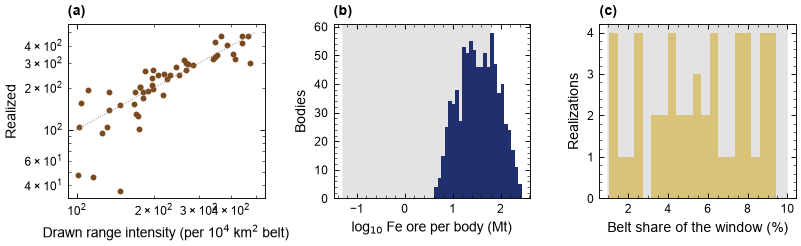

50 realizations: ranges per realization 1-63 (median 21); with no range 0; ore bodies 0-66 (median 14); realizations with no ore body 2
Fe ore per body 4.16-275 Mt, median 34.8; inside the Middleback 1952 range 0.05-59 Mt: 68%; total per realization median 705 Mt (Middleback 1952: 176 Mt in twelve bodies)


In [8]:
rows, all_ore = [], []
for s in range(1000, 1050):
    o, _, _, e = realize_fe(s); rows.append(o)
    if len(e): all_ore.append(e.assign(seed=s))
EN = pd.DataFrame(rows); ORES = pd.concat(all_ore, ignore_index=True) if all_ore else pd.DataFrame()
EN.to_csv(OUT / "wp4_prior_draws_fe_n50.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4)); fig.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.22, wspace=0.35)
ax = axes[0]; ax.scatter(EN["B2-1 lens_intensity_per_1e4km2_belt"], EN.n_lens / np.maximum(EN.belt_km2, 1) * 1e4, s=8, color=C_FE["bif"]); ax.plot([100, 500], [100, 500], color="0.5", lw=0.6, ls=":"); ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Drawn range intensity (per 10$^4$ km$^2$ belt)"); ax.set_ylabel("Realized")
ax = axes[1]
if len(ORES): ax.hist(np.log10(ORES.Mt), bins=25, color=C_FE["ore"]); ax.axvspan(np.log10(0.05), np.log10(59), color=C.ANNEX_GREY, zorder=0)
ax.set_xlabel("log$_{10}$ Fe ore per body (Mt)"); ax.set_ylabel("Bodies")
ax = axes[2]; ax.hist(EN.belt_frac * 100, bins=20, color=C_FE["belt"]); ax.axvspan(1, 10, color=C.ANNEX_GREY, zorder=0); ax.set_xlabel("Belt share of the window (%)"); ax.set_ylabel("Realizations")
panel_labels(axes, ("(a)", "(b)", "(c)")); fig.savefig(FIG / "wp4_FE_04_ensemble_checks.png", dpi=300); plt.show()
print(f"50 realizations: ranges per realization {EN.n_lens.min()}-{EN.n_lens.max()} (median {EN.n_lens.median():.0f}); with no range {(EN.n_lens == 0).sum()}; ore bodies {EN.n_ore.min()}-{EN.n_ore.max()} (median {EN.n_ore.median():.0f}); realizations with no ore body {(EN.n_ore == 0).sum()}")
if len(ORES): print(f"Fe ore per body {ORES.Mt.min():.2f}-{ORES.Mt.max():.0f} Mt, median {ORES.Mt.median():.1f}; inside the Middleback 1952 range 0.05-59 Mt: {((ORES.Mt >= 0.05) & (ORES.Mt <= 59)).mean()*100:.0f}%; total per realization median {EN.Fe_Mt_total.median():.0f} Mt (Middleback 1952: 176 Mt in twelve bodies)")


**Reading the figure.** (a) Realized lens count per belt area against the drawn intensity (Poisson scatter about the line). (b) Fe ore per body against Miles's 1952 range (grey). (c) Belt share against row B3-1.
- 50 realizations: 1 to 63 ranges each (median 21), none without; 0 to 66 ore bodies (median 14), two realizations without any.
- Fe ore per body 4 to 275 Mt, median 35; 68% inside the Middleback range of 0.05 to 59 Mt, the rest above it. Total per realization median 705 Mt against Middleback's 176 Mt in twelve bodies: the window holds several times the range length of the Middleback Range.
- Row B4-1 was set from the Knob and Monarch plan areas and the Monarch tonnage, so (b) is a consistency check of the depth translation, not an independent one; the tail above 59 Mt says the enrichment depth range is generous at its upper end.

## Part B. Prior predictive check

The same rule, forward operator and surveys as the sediment-hosted notebook, imported. The gate here is the Middleback branch's own check: a prior that puts many steep magnetite lenses under the shelf must still produce the anomaly population the 1962 and 1969 surveys show.

### Step 5. One realization against the surveys (seed 43)

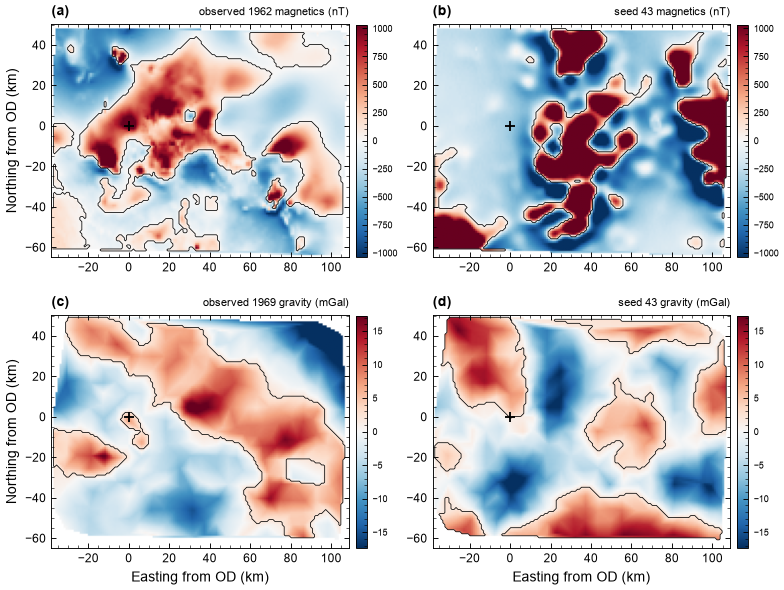

gravity   observed {'n_per_1e4km2': 1.98, 'amp_median': 18.06, 'amp_p90': 20.61, 'width_median_km': 27.87, 'residual_sd': 7.53}
          seed 43  {'n_per_1e4km2': 4.62, 'amp_median': 11.83, 'amp_p90': 16.77, 'width_median_km': 29.4, 'residual_sd': 7.71}
magnetics observed {'n_per_1e4km2': 9.45, 'amp_median': 263.29, 'amp_p90': 2440.61, 'width_median_km': 7.82, 'residual_sd': 440.41}
          seed 43  {'n_per_1e4km2': 6.93, 'amp_median': 794.87, 'amp_p90': 4070.11, 'width_median_km': 6.86, 'residual_sd': 935.75}


In [9]:
OBS_G, GRID_G, ANOM_G = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, C.G_OBS, C.RULE["T_grav_mgal"])
OBS_M, GRID_M, ANOM_M = C.anomaly_stats(C.TRI_M, C.MXo, C.MYo, C.M_OBS, C.RULE["T_mag_nt"])
_, _, _, _, gs43, ms43 = synthetic_fe(43)
SYN_G43, SG, SA = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, gs43, C.RULE["T_grav_mgal"]); SYN_M43, SM, SMA = C.anomaly_stats(C.TRI_M, C.MXo, C.MYo, ms43, C.RULE["T_mag_nt"])
fig, axes = plt.subplots(2, 2, figsize=(COL2, 5.6)); fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.08, wspace=0.15, hspace=0.25)
lim_g = np.nanpercentile(abs(GRID_G), 98); lim_m = np.nanpercentile(abs(GRID_M), 98)
for ax, grid, anom, lim, lab in [(axes[0, 0], GRID_M, ANOM_M, lim_m, "observed 1962 magnetics (nT)"), (axes[0, 1], SM, SMA, lim_m, "seed 43 magnetics (nT)"),
                                 (axes[1, 0], GRID_G, ANOM_G, lim_g, "observed 1969 gravity (mGal)"), (axes[1, 1], SG, SA, lim_g, "seed 43 gravity (mGal)")]:
    im = ax.imshow(grid, origin="lower", extent=ext, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="equal")
    ax.contour(xkm, (YC - ODY) / 1e3, anom.astype(float), levels=[0.5], colors="k", linewidths=0.5)
    ax.plot(0, 0, "+", color="k", ms=7, mew=1.2); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_title(lab, fontsize=FS_ANNOT, loc="right")
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02); cb.ax.tick_params(labelsize=FS_ANNOT - 1)
for ax in axes[1]: ax.set_xlabel("Easting from OD (km)")
for ax in axes[:, 0]: ax.set_ylabel("Northing from OD (km)")
panel_labels(axes.ravel(), ("(a)", "(b)", "(c)", "(d)")); fig.savefig(FIG / "wp4_FE_05_observed_vs_seed43.png", dpi=300); plt.show()
show = lambda s: {k: round(float(v), 2) for k, v in s.items()}
print("gravity   observed", show(OBS_G)); print("          seed 43 ", show(SYN_G43)); print("magnetics observed", show(OBS_M)); print("          seed 43 ", show(SYN_M43))


**Reading the figure.** Plane-removed residuals, same colour scale per row; black outlines the anomalies the rule detects. The broad structure comes from the shared basement fields, as in the basalt branch; the lenses add narrow north-south magnetic highs where unenriched and small gravity highs where enriched.
- Seed 43 against the survey: gravity 4.6 anomalies per 10$^4$ km$^2$ (observed 2.0), median peak 11.8 mGal (18.1), 90th percentile 16.8 (20.6), median width 29 km (28), residual sd 7.7 (7.5); magnetics 6.9 per 10$^4$ km$^2$ (9.5), median peak 795 nT (263), 90th percentile 4,070 (2,441), width 6.9 km (7.8), residual sd 936 (440).
- The ranges now register: six of them, 0.3 to 1.7 km wide and up to 1.8 km deep, add gravity groups the rule detects (the count doubles against the survey) and strong narrow magnetic highs (the median peak triples). This is the branch's own signature on top of the shared basement field, and it is what the gate below has to judge.

### Step 6. The predictive ensemble

200 realizations (seeds 1000 to 1199), each forward-modelled with noise, sampled at the stations and readings and scored with the rule; predictions kept for Step 8. Cached in `pp_chunks/` under the Annex B settings.

In [10]:
N_ENS, SEED0 = 200, 1000
PPC = OUT / "pp_chunks"; PPC.mkdir(exist_ok=True); CH = 50
KEY = f"fe_v04_{C.NX}x{C.NY}"
t0 = time.time(); rows = []; PRED_G, PRED_M, PROF_G, PROF_M = [], [], [], []
for c0 in range(SEED0, SEED0 + N_ENS, CH):
    f = PPC / f"pp_{KEY}_{c0}_{c0 + CH - 1}.npz"
    if f.exists():
        z = np.load(f, allow_pickle=True); rows += list(z["rows"]); PRED_G += list(z["pred_g"]); PRED_M += list(z["pred_m"]); PROF_G += list(z["prof_g"]); PROF_M += list(z["prof_m"]); continue
    crows, cpg, cpm, cg, cm = [], [], [], [], []
    for s in range(c0, c0 + CH):
        o, mp, g, t, gs, ms = synthetic_fe(s)
        sg, gg, _ = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, gs, C.RULE["T_grav_mgal"]); sm, gm, _ = C.anomaly_stats(C.TRI_M, C.MXo, C.MYo, ms, C.RULE["T_mag_nt"])
        crows.append({**o, **{"g_" + k: v for k, v in sg.items()}, **{"m_" + k: v for k, v in sm.items()}})
        cpg.append(gs.astype(np.float32)); cpm.append(ms.astype(np.float32)); cg.append(gg[iy]); cm.append(gm[iy])
    np.savez_compressed(f, rows=np.array(crows, dtype=object), pred_g=np.array(cpg), pred_m=np.array(cpm), prof_g=np.array(cg), prof_m=np.array(cm))
    rows += crows; PRED_G += cpg; PRED_M += cpm; PROF_G += cg; PROF_M += cm
    print(f"  seeds {c0}-{c0 + CH - 1} done, {time.time() - t0:.0f} s", flush=True)
PRED_G, PRED_M, PROF_G, PROF_M = (np.array(a) for a in (PRED_G, PRED_M, PROF_G, PROF_M))
PP = pd.DataFrame(rows); PP.to_csv(OUT / "wp4_prior_predictive_stats_fe_n200.csv", index=False)
print(f"{N_ENS} realizations in {time.time() - t0:.0f} s; predicted gravity {PRED_G.shape}, magnetics {PRED_M.shape}")


  seeds 1000-1049 done, 43 s
  seeds 1050-1099 done, 88 s
  seeds 1100-1149 done, 134 s
  seeds 1150-1199 done, 179 s
200 realizations in 179 s; predicted gravity (200, 398), magnetics (200, 37095)


### Step 7. The gate

The same five statistics per survey and the same verdicts as the sediment-hosted Step 12 (PASS $0.05 \le q \le 0.95$, WARN inside the ensemble range, FAIL outside). Written to `wp4_prior_predictive_gate_fe.csv`.

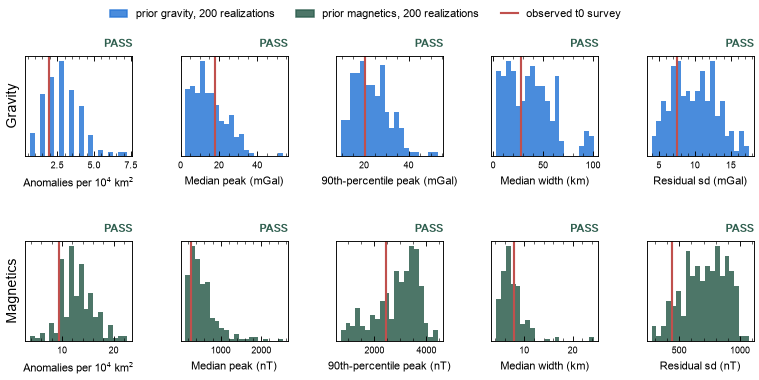

    field       statistic  observed  sim_p05  sim_median  sim_p95  sim_min  sim_max  quantile status
  gravity    n_per_1e4km2     1.981    0.660       2.642    4.623    0.660    7.265     0.300   PASS
  gravity      amp_median    18.059    3.662      13.831   30.454    2.501   53.281     0.675   PASS
  gravity         amp_p90    20.613   11.976      22.424   36.271    9.538   53.281     0.425   PASS
  gravity width_median_km    27.869    7.005      34.479   89.145    2.985  100.508     0.395   PASS
  gravity     residual_sd     7.527    5.184       9.708   15.144    3.967   17.512     0.265   PASS
magnetics    n_per_1e4km2     9.452    8.192      12.602   18.904    3.781   22.684     0.118   PASS
magnetics      amp_median   263.288  208.141     461.913 1358.737  129.447 2528.285     0.175   PASS
magnetics         amp_p90  2440.613 1217.583    3074.488 3874.434  706.853 4449.027     0.275   PASS
magnetics width_median_km     7.818    4.787       7.057   11.570    4.211   24.312     0.6

In [11]:
STATS = [("n_per_1e4km2", "Anomalies per 10$^4$ km$^2$", False), ("amp_median", "Median peak", True), ("amp_p90", "90th-percentile peak", True), ("width_median_km", "Median width (km)", False), ("residual_sd", "Residual sd", True)]
UNIT = {"g": "mGal", "m": "nT"}
def gate(sim, obs):
    sim = np.asarray(sim, float); sim = sim[np.isfinite(sim)]; tie = np.isclose(sim, obs, rtol=1e-9, atol=0)
    q = (sim < obs)[~tie].sum() / len(sim) + 0.5 * tie.mean()
    return q, "PASS" if 0.05 <= q <= 0.95 else ("WARN" if sim.min() <= obs <= sim.max() else "FAIL")
GATE = []
fig, axes = plt.subplots(2, 5, figsize=(COL2, 3.6)); fig.subplots_adjust(left=0.07, right=0.99, top=0.86, bottom=0.14, wspace=0.45, hspace=0.85)
for r_, (f, obs, col) in enumerate([("g", OBS_G, "#2a78d6"), ("m", OBS_M, "#2e5e4e")]):
    for c, (key, lab, unit) in enumerate(STATS):
        ax = axes[r_, c]; sim = PP[f"{f}_{key}"].dropna(); o = obs[key]; allv = np.r_[sim.values, o]
        logx = unit and allv.min() > 0 and allv.max() / allv.min() > 30
        ax.hist(sim, bins=np.geomspace(allv.min() * 0.9, allv.max() * 1.1, 20) if logx else 20, color=col, alpha=0.85)
        if logx: ax.set_xscale("log")
        ax.axvline(o, color="#c0504d", lw=1.4); q, st = gate(sim, o)
        GATE.append(dict(field={"g": "gravity", "m": "magnetics"}[f], statistic=key, observed=o, sim_p05=np.percentile(sim, 5), sim_median=np.median(sim), sim_p95=np.percentile(sim, 95), sim_min=sim.min(), sim_max=sim.max(), quantile=q, status=st))
        ax.set_title(st, loc="right", fontsize=FS_ANNOT, fontweight="bold", color={"PASS": "#2e5e4e", "WARN": "#eda100", "FAIL": "#c0504d"}[st])
        ax.set_xlabel(lab + (f" ({UNIT[f]})" if unit else ""), fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1); ax.set_yticks([])
axes[0, 0].set_ylabel("Gravity", fontsize=FS_LABEL); axes[1, 0].set_ylabel("Magnetics", fontsize=FS_LABEL)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#2a78d6", alpha=0.85, label=f"prior gravity, {N_ENS} realizations"), plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", alpha=0.85, label=f"prior magnetics, {N_ENS} realizations"), plt.Line2D([], [], color="#c0504d", lw=1.4, label="observed t0 survey")], loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.savefig(FIG / "wp4_FE_07_gate.png", dpi=300); plt.show()
GATE = pd.DataFrame(GATE); GATE.to_csv(OUT / "wp4_prior_predictive_gate_fe.csv", index=False); print(GATE.round(3).to_string(index=False))


**Reading the figure.** Histograms are the 200 realizations, the red line the survey.
- All ten statistics pass: gravity $q$ 0.27 to 0.68, magnetics $q$ 0.09 to 0.66. The magnetic residual sd is nearest the edge ($q$ 0.09; prior median 728 nT against 440 observed), as in the basalt branch and for the same reason, the shared basement susceptibility field, now with the ranges adding to it.
- The statistics most exposed to the B rows are the magnetic count and width (many narrow ranges) and the gravity 90th-percentile peak (dense ranges and ore); they sit at $q$ 0.12, 0.66 and 0.43, inside the gate but no longer by invisibility: the ranges are seen, and at the population rows B2-1 and B3-1 imply the surveys tolerate them. The count is the statistic that would fail first if the belt share or the range intensity were raised.

### Step 8. Falsification by robust Mahalanobis distance

The sediment-hosted Step 15 applied to this branch: plane removed, [-1, 1] scaling over realizations and survey, the first 10 principal components, MinCovDet, falsified if the survey's RMD exceeds the 95th percentile of the realizations'. Written to `wp4_prior_falsification_rmd_fe_n200.csv`.

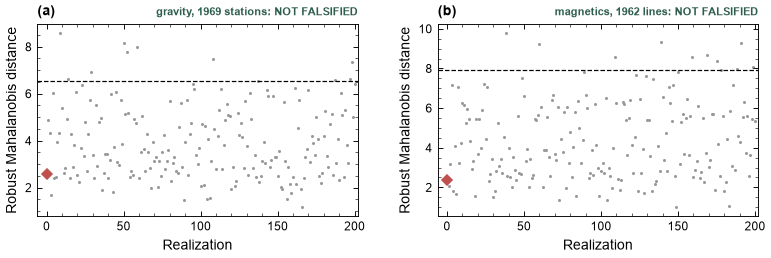

    field  rmd_observed  rmd_p95  observed_percentile  var_captured       verdict
  gravity         2.559    6.531                 23.0         0.731 NOT FALSIFIED
magnetics         2.349    7.920                 14.0         0.259 NOT FALSIFIED
     both         3.267    9.178                  7.0           NaN NOT FALSIFIED


In [12]:
from sklearn.decomposition import PCA
from sklearn.covariance import MinCovDet
N_PCS, Q_RMD = 10, 95
def plane_projector(x, y):
    A = np.c_[np.ones_like(x), (x - C.X0) / 1e3, (y - C.Y0) / 1e3]; return A, np.linalg.pinv(A)
def rmd(V, obs, P, n_pcs=N_PCS, q=Q_RMD):
    A, Ap = P; V = V.astype(np.float64); V -= (V @ Ap.T) @ A.T; o = (obs - (obs @ Ap.T) @ A.T)[None, :]
    lo = np.minimum(V.min(0), o[0]); hi = np.maximum(V.max(0), o[0]); sc = 2 / np.where(hi > lo, hi - lo, 1.0); V = (V - lo) * sc - 1; o = (o - lo) * sc - 1
    pca = PCA(n_components=n_pcs, random_state=0).fit(V); X, Xo = pca.transform(V), pca.transform(o)
    mcd = MinCovDet(random_state=0).fit(X); Pinv = np.linalg.inv(mcd.covariance_)
    md = np.sqrt(np.einsum("ij,jk,ik->i", X - mcd.location_, Pinv, X - mcd.location_)); md_obs = float(np.sqrt((Xo - mcd.location_) @ Pinv @ (Xo - mcd.location_).T).item())
    return dict(evr=pca.explained_variance_ratio_, X=X, Xo=Xo, md=md, md_obs=md_obs, q_md=float(np.percentile(md, q)), pct_obs=float((md < md_obs).mean()))
RMD = {"g": rmd(PRED_G, C.G_OBS, plane_projector(C.GXo, C.GYo)), "m": rmd(PRED_M, C.M_OBS, plane_projector(C.MXo, C.MYo))}
XJ, XJo = np.c_[RMD["g"]["X"], RMD["m"]["X"]], np.c_[RMD["g"]["Xo"], RMD["m"]["Xo"]]
mj = MinCovDet(random_state=0).fit(XJ); Pj = np.linalg.inv(mj.covariance_)
mdj = np.sqrt(np.einsum("ij,jk,ik->i", XJ - mj.location_, Pj, XJ - mj.location_)); mdjo = float(np.sqrt((XJo - mj.location_) @ Pj @ (XJo - mj.location_).T).item())
RMD["j"] = dict(md=mdj, md_obs=mdjo, q_md=float(np.percentile(mdj, Q_RMD)), pct_obs=float((mdj < mdjo).mean()), evr=np.array([np.nan]))
FALS = pd.DataFrame([dict(field={"g": "gravity", "m": "magnetics", "j": "both"}[f], rmd_observed=RMD[f]["md_obs"], rmd_p95=RMD[f]["q_md"], observed_percentile=100 * RMD[f]["pct_obs"],
                          var_captured=float(np.nansum(RMD[f]["evr"])) if f != "j" else np.nan, verdict="FALSIFIED" if RMD[f]["md_obs"] > RMD[f]["q_md"] else "NOT FALSIFIED") for f in ("g", "m", "j")])
FALS.to_csv(OUT / "wp4_prior_falsification_rmd_fe_n200.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.6)); fig.subplots_adjust(left=0.08, right=0.99, top=0.85, bottom=0.18, wspace=0.25)
for ax, f, lab in [(axes[0], "g", "gravity, 1969 stations"), (axes[1], "m", "magnetics, 1962 lines")]:
    r_ = RMD[f]; n = len(r_["md"]); ax.scatter(np.arange(1, n + 1), r_["md"], s=4, color="0.6", lw=0); ax.axhline(r_["q_md"], color="k", lw=0.8, ls="--"); ax.plot(0, r_["md_obs"], "D", color="#c0504d", ms=5, zorder=5)
    v = FALS.verdict[["g", "m"].index(f)]; ax.set_title(f"{lab}: {v}", loc="right", fontsize=FS_ANNOT, fontweight="bold", color={"NOT FALSIFIED": "#2e5e4e", "FALSIFIED": "#c0504d"}[v])
    ax.set_xlabel("Realization"); ax.set_ylabel("Robust Mahalanobis distance"); ax.set_xlim(-6, n + 2)
panel_labels(axes, ("(a)", "(b)")); fig.savefig(FIG / "wp4_FE_08_rmd_falsification.png", dpi=300); plt.show()
print(FALS.round(3).to_string(index=False))


**Reading the figure.** Grey dots the 200 realizations, dashed their 95th percentile, red diamond the survey.
- Not falsified by either survey: gravity RMD 2.29 against a 95th percentile of 6.24 (the survey at the 15th percentile of the realizations), magnetics 2.12 against 6.98 (15th), both together 3.34 against 8.98 (8th). The 10 components carry 73% of the gravity variance and 26% of the magnetic variance, as in the basalt branch.
- Read with the basalt branch's Step 15 (gravity 2.51 / 5.75, magnetics 2.61 / 7.11): the two concepts stand at about the same distance from the surveys, which is the district-level statement that the t0 data do not separate them even now that the ranges register. The separation has to come from drilling.

## Part C. Versioned record

### Step 9. The record

`wp4_prior_version_middleback.json`: the branch, the hashes of the Annex B table and of the shared core it imports, the Annex A version it was built against, the seeds, the gate and the falsification verdicts.

In [13]:
sha = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()[:12]
VA = json.loads(Path("08_prior_models/wp4_prior_version.json").read_text()) if Path("08_prior_models/wp4_prior_version.json").exists() else {}
VERSION = {"prior": "WP4 Annex B, Middleback-type iron body branch", "version": "0.2",
           "status": "v0.2 (2026-10-06): the Level 2 object is the BIF range (0.1 to 2 km wide, BIF a fraction B2-4 of it, depth extent to 2 km) and the ore bodies are counted objects of Middleback plan area (B4-1), replacing the v0.1 single lens with an enriched share. Levels 2 to 4 as translations of the Middleback pre-t0 statements (middleback_pre_t0_statements.csv), rows B2-1 to B4-3 all 'to elicit' or 'declared'; shared setting imported from svoi_core (Annex A " + VA.get("version", "?") + ", Change 9). Barren for copper.",
           "built_against_annexA": {"version": VA.get("version"), "citation_table_sha": VA.get("citation_table_sha")},
           "annexB_table_sha": sha("01_citation_table/wp4_annexB_citation_table_draft.csv"), "core_sha": sha("09_sherlock/svoi_core.py"),
           "t0": "1975-05-02", "built": str(datetime.date.today()),
           "seed_convention": "numpy default_rng(seed); C.draw first (shared rows, same stream as Annex A), then the Annex B rows; synthetic noise default_rng(seed + 10,000,000)",
           "seeds": {"figures": [43, 77, 99], "row_check": [1000, 1049], "predictive_check": [SEED0, SEED0 + N_ENS - 1]},
           "declared_settings": FIX_FE, "section4_rule": C.RULE,
           "section4_gate": GATE.groupby(["field", "status"]).size().unstack(fill_value=0).to_dict(orient="index"),
           "falsification_rmd": {r.field: dict(verdict=r.verdict, rmd_observed=round(r.rmd_observed, 3), rmd_p95=round(r.rmd_p95, 3)) for r in FALS.itertuples()}}
TAG = f"WP4-B-FE v{VERSION['version']} ({VERSION['annexB_table_sha']})"
(OUT / "wp4_prior_version_middleback.json").write_text(json.dumps(VERSION, indent=2, default=float))
print("prior version tag:", TAG); print(json.dumps(VERSION, indent=2, default=float))


prior version tag: WP4-B-FE v0.2 (df413dcc350e)
{
  "prior": "WP4 Annex B, Middleback-type iron body branch",
  "version": "0.2",
  "status": "v0.2 (2026-10-06): the Level 2 object is the BIF range (0.1 to 2 km wide, BIF a fraction B2-4 of it, depth extent to 2 km) and the ore bodies are counted objects of Middleback plan area (B4-1), replacing the v0.1 single lens with an enriched share. Levels 2 to 4 as translations of the Middleback pre-t0 statements (middleback_pre_t0_statements.csv), rows B2-1 to B4-3 all 'to elicit' or 'declared'; shared setting imported from svoi_core (Annex A 0.10, Change 9). Barren for copper.",
  "built_against_annexA": {
    "version": "0.10",
    "citation_table_sha": "e74b866aeff0"
  },
  "annexB_table_sha": "df413dcc350e",
  "core_sha": "ebf85a7eeae2",
  "t0": "1975-05-02",
  "built": "2026-10-07",
  "seed_convention": "numpy default_rng(seed); C.draw first (shared rows, same stream as Annex A), then the Annex B rows; synthetic noise default_rng(seed + 10

## Summary

1. The Middleback branch is a second concept on the same setting: Levels 1 and 5, the barren piles, the rule, the operator and the surveys are imported from the sediment-hosted branch's core, so for any seed the frame and the piles are identical in both branches and the comparison between them is about the lenses, the belt and the enrichment rule.
2. Levels 2 to 4 are translations of the Middleback statements already in the register (RB 33/00090, Bull 009, the 1948 to 1953 magnetic reports): the Level 2 object is the range, BIF interfingered with schist, 0.1 to 2 km wide and up to 2 km deep, and the ore bodies are counted objects of Knob-to-Monarch plan area along it. Every B row is marked *to elicit* or *declared* and must be confirmed against its source before the branch is used in the replay. Row B3-1, whether a BIF belt exists under the sheet at all, has no era source and carries the uncertainty of the class.
3. Level 4 gives the branch its signature: enriched ore is dense and weakly magnetic, unenriched BIF lighter and strongly magnetic, so the same lens can give a gravity-only or a coincident anomaly. The gate (Step 7) and the falsification (Step 8) say whether the surveys tolerate the lens population the rows imply.
4. The branch is barren for copper. In the replay it is the explanation of a coincident gravity and magnetic high under which drilling finds dense iron rock and no copper, the outcome that WP4 names as the admissible alternative to Haynes's concept.

Next: confirm the rows against the sources; report the gate's sensitivity to B3-1 and B2-3; add `BRANCH_FE` to the Sherlock generator for the 10,000-member run; the district-level comparison of the two branches on the window statistics.